In [ ]:

!pip install gensim nltk scikit-learn tensorflow pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.0 MB/s eta 0:00:00


In [ ]:
!pip install gensim # Ensuring gensim is available
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import gensim.downloader as api

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:

from google.colab import files
uploaded = files.upload()


Saving Book_review.csv to Book_review.csv


In [ ]:

df = pd.read_csv('Book_review.csv')

print(df.head())
print(df.shape)


   Unnamed: 0  rating                                         reviewText  \
0           0       5  This book was the very first bookmobile book I...   
1           1       1  When I read the description for this book, I c...   
2           2       5  I just had to edit this review. This book is a...   
3           3       5  I don't normally buy 'mystery' novels because ...   
4           4       5  This isn't the kind of book I normally read, a...   

                           summary  
0                50 + years ago...  
1          Boring! Boring! Boring!  
2  Wiggleliscious/new toy ready/!!  
3                  Very good read.  
4                     Great Story!  
(12000, 4)


In [ ]:

df['summary'] = df['summary'].fillna('')
df['reviewText'] = df['reviewText'].fillna('')

df['text'] = df['summary'] + ' ' + df['reviewText']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

print(df[['text']].head())


                                                text
0    years ago this book was the very first bookm...
1  boring boring boring when i read the descripti...
2  wigglelisciousnew toy ready i just had to edit...
3  very good read i dont normally buy mystery nov...
4  great story this isnt the kind of book i norma...


In [ ]:

def sentiment_label(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

df['sentiment'] = df['rating'].apply(sentiment_label)

print(df['sentiment'].value_counts())


sentiment
2    6000
0    4000
1    2000
Name: count, dtype: int64


In [ ]:

MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])

X = pad_sequences(sequences, maxlen=MAX_LEN)

y = to_categorical(df['sentiment'], num_classes=3)

print(X.shape)
print(y.shape)


(12000, 200)
(12000, 3)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(9600, 200)
(2400, 200)


In [ ]:

rnn_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    SimpleRNN(72),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.5072 - loss: 1.0024 - val_accuracy: 0.5703 - val_loss: 0.9692
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - accuracy: 0.7122 - loss: 0.6977 - val_accuracy: 0.6844 - val_loss: 0.7577
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - accuracy: 0.8671 - loss: 0.3472 - val_accuracy: 0.6693 - val_loss: 0.8700
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.9646 - loss: 0.1160 - val_accuracy: 0.6427 - val_loss: 1.1041


In [ ]:

loss_rnn, acc_rnn = rnn_model.evaluate(X_test, y_test)

print('Simple RNN Accuracy:', acc_rnn)
print('Simple RNN Loss:', loss_rnn)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6975 - loss: 0.7568
Simple RNN Accuracy: 0.6974999904632568
Simple RNN Loss: 0.7568075656890869


In [ ]:

bilstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(80)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 86s 678ms/step - accuracy: 0.6223 - loss: 0.8589 - val_accuracy: 0.7083 - val_loss: 0.7065
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 668ms/step - accuracy: 0.7684 - loss: 0.5806 - val_accuracy: 0.7234 - val_loss: 0.6538
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 80s 664ms/step - accuracy: 0.8387 - loss: 0.4083 - val_accuracy: 0.7078 - val_loss: 0.6813
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 80s 666ms/step - accuracy: 0.8898 - loss: 0.2934 - val_accuracy: 0.7073 - val_loss: 0.7776


In [ ]:

loss_bilstm, acc_bilstm = bilstm_model.evaluate(X_test, y_test)

print('BiLSTM Accuracy:', acc_bilstm)
print('BiLSTM Loss:', loss_bilstm)


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7442 - loss: 0.6330
BiLSTM Accuracy: 0.7441666722297668
BiLSTM Loss: 0.6330407857894897


### Model Performance Visualization

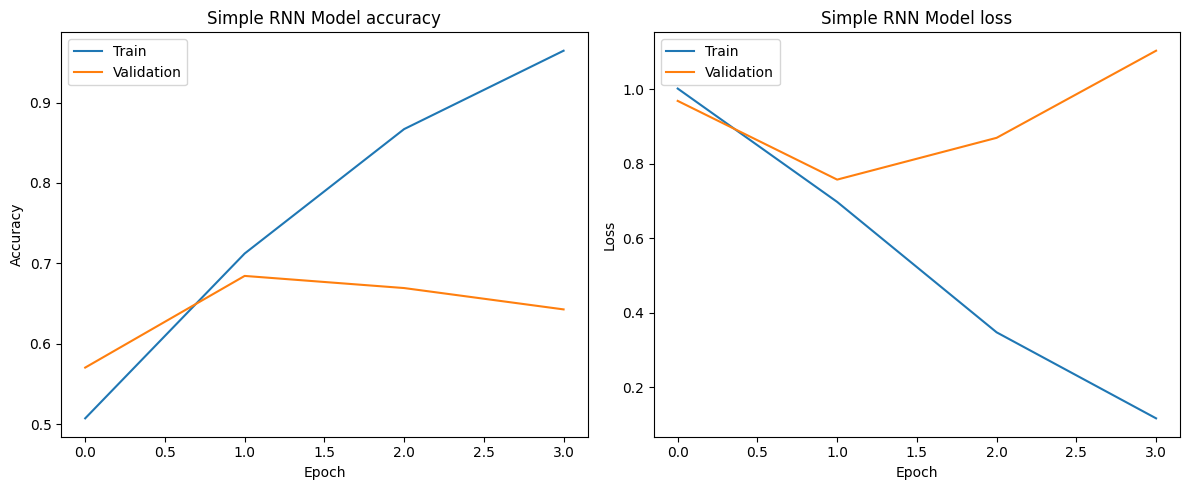

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values for Simple RNN
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])
plt.title('Simple RNN Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for Simple RNN
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])
plt.title('Simple RNN Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

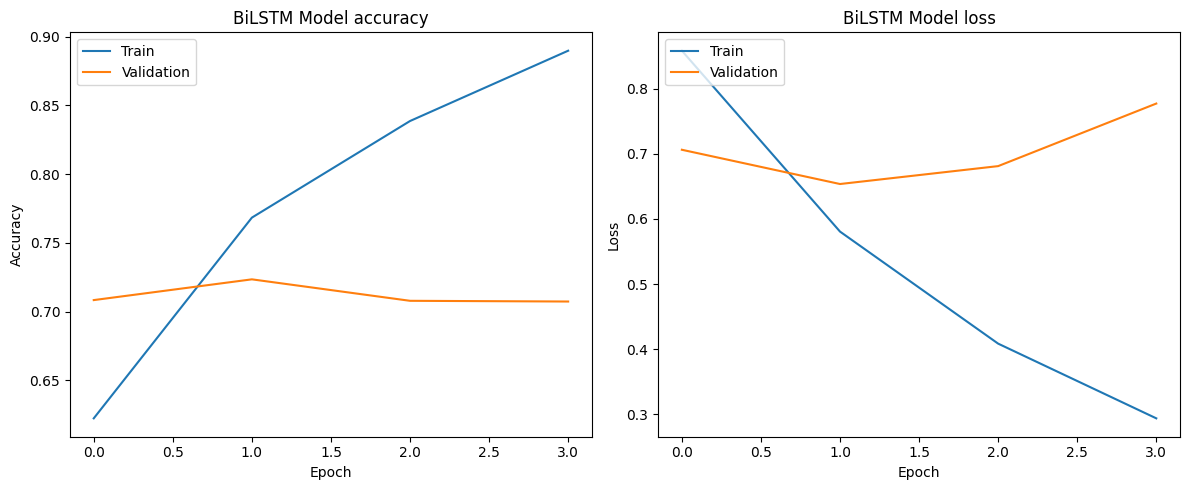

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values for BiLSTM
plt.subplot(1, 2, 1)
plt.plot(history_bilstm.history['accuracy'])
plt.plot(history_bilstm.history['val_accuracy'])
plt.title('BiLSTM Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values for BiLSTM
plt.subplot(1, 2, 2)
plt.plot(history_bilstm.history['loss'])
plt.plot(history_bilstm.history['val_loss'])
plt.title('BiLSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

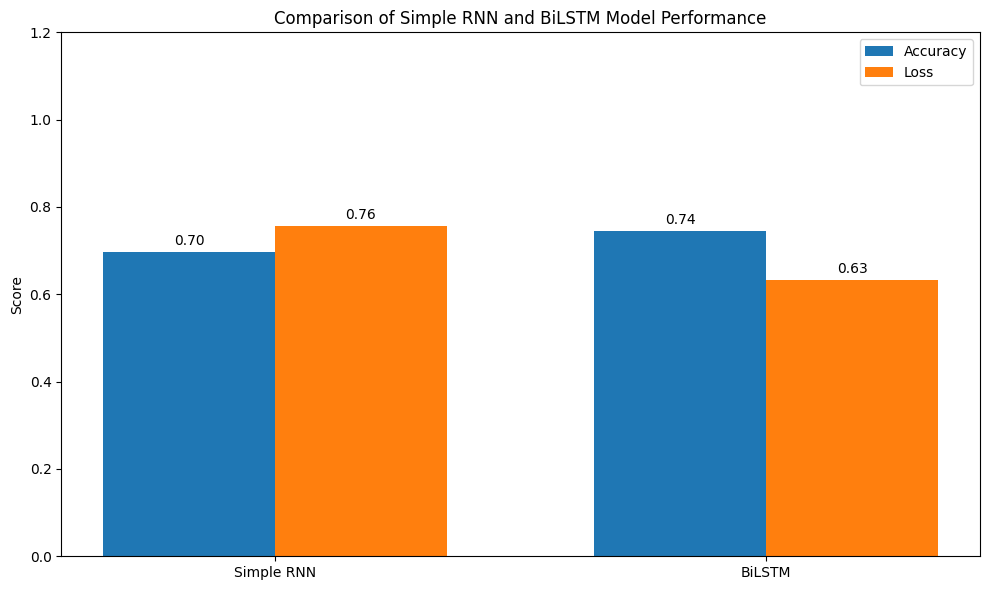

In [ ]:
models = ['Simple RNN', 'BiLSTM']
accuracies = [acc_rnn, acc_bilstm]
losses = [loss_rnn, loss_bilstm]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy')
rects2 = ax.bar(x + width/2, losses, width, label='Loss')

ax.set_ylabel('Score')
ax.set_title('Comparison of Simple RNN and BiLSTM Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0, 1.2) # Adjust y-axis limit for better visualization
plt.tight_layout()
plt.show()